# Color Enhancement Methods


## Color Enhancement based method

1.**Gamma Correction:** Adjusts the brightness of an image by transforming pixel values using a gamma value.


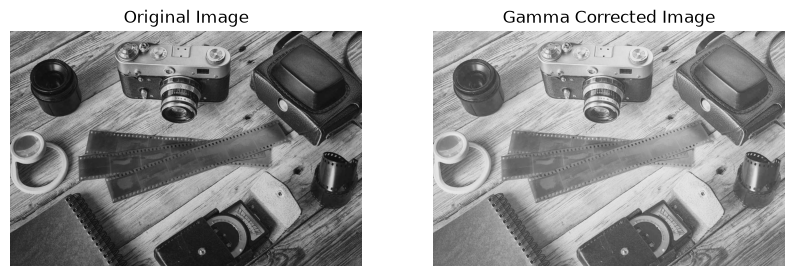

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def gamma_correction(image, gamma=1.0):
    invGamma = 1.0 / gamma
    table = np.array(
        [((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]
    ).astype("uint8")
    return cv2.LUT(image, table)


image = cv2.imread("../images/samplecamera.jpg")
gamma_corrected = gamma_correction(image, gamma=2.0)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Gamma Corrected Image")
plt.imshow(cv2.cvtColor(gamma_corrected, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

## Histogram-Based Methods

**Contrast-Limited Adaptive Histogram Equalization (CLAHE):** Enhances contrast in small regions of the image.


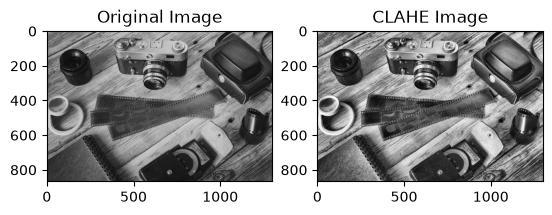

In [ ]:
def clahe(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if image is not None:
        if len(image.shape) == 2:
            return clahe.apply(image)
        elif len(image.shape) == 3:
            channels = cv2.split(image)
            clahe_channels = [clahe.apply(ch) for ch in channels]
            return cv2.merge(clahe_channels)
    else:
        return None


image_path = cv2.imread("../images/samplecamera.jpg")

image = cv2.imread("../images/samplecamera.jpg", 0)
clahe_image = clahe(image)

if clahe_image is not None:
    plt.Figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image, cmap="gray")
    plt.subplot(1, 2, 2)
    plt.title("CLAHE Image")
    plt.imshow(clahe_image, cmap="gray")
    plt.show()
else:
    print("Failed to load or apply CLAHE")